# **Exercise 1**

In [ ]:
# load functions and data
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns

df = sns.load_dataset("penguins")
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [ ]:
df.fillna(df.select_dtypes(include='number').mean().round(1), inplace=True)
# df.fillna(df.mean(),inplace=True)
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,43.9,17.2,200.9,4201.8,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,43.9,17.2,200.9,4201.8,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


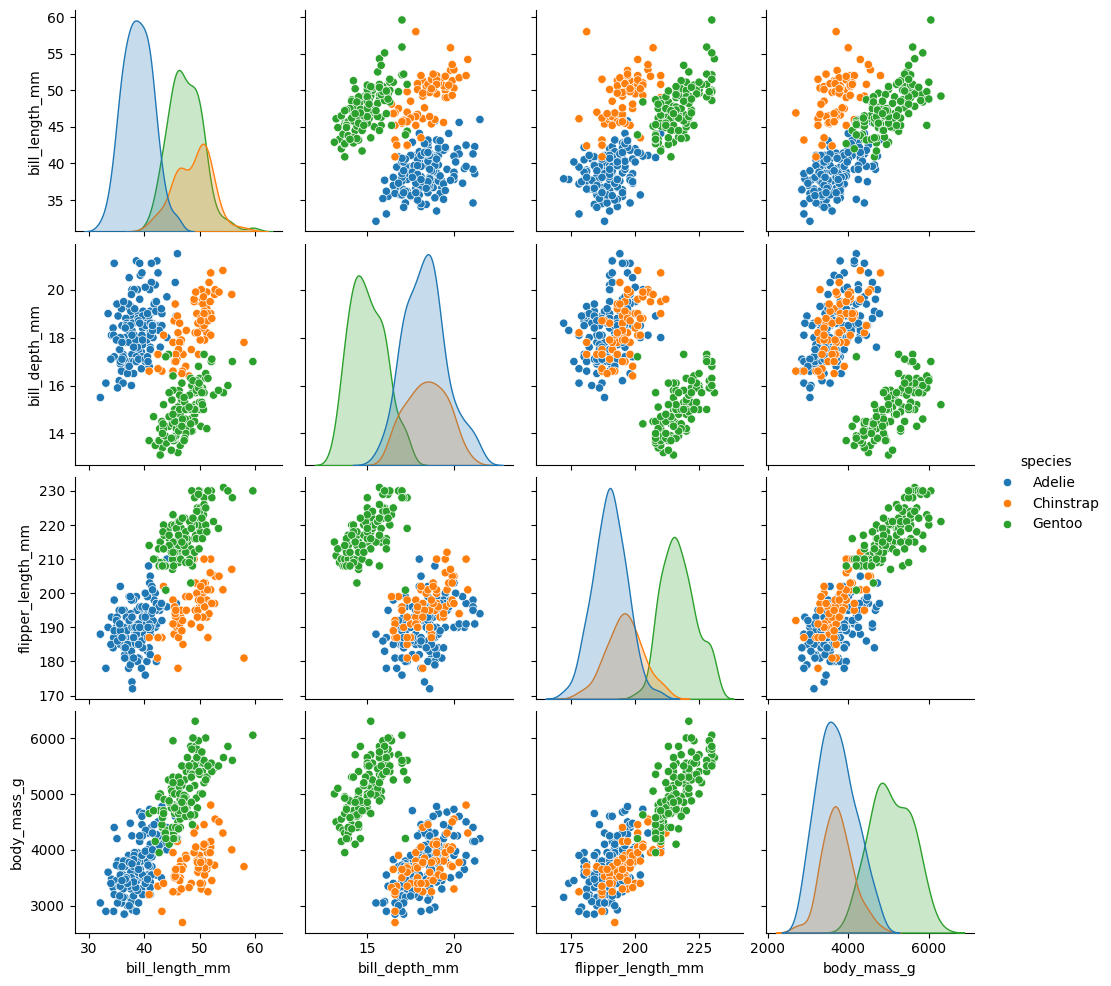

In [ ]:
# 1.a create again a pairplot with hue on species
sns.pairplot(df, hue='species')

In [ ]:
# 1.b create a correlation table by applying the .corr() method to a dataframe
df.select_dtypes(include='number').corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583850,-0.471915
flipper_length_mm,0.656181,-0.583850,1.000000,0.871202
body_mass_g,0.595110,-0.471915,0.871202,1.000000


<Axes: >

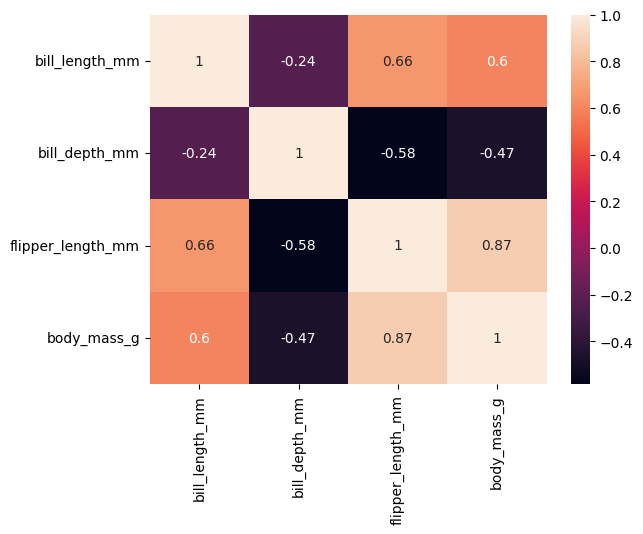

In [ ]:
# 1.c add the correlation table to seaborns heatmap function
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

# **Exercise 2**

# Exploratory Data Analysis (EDA)

In [149]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt

# load data and store in variable df
df = pd.read_csv('https://drive.google.com/uc?id=1Rzq2VqPVRM2kfMuh_jToJKzKUvBOC0vp')

df.head()

,id,price,neighbourhood_group_cleansed,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,bed_type,minimum_nights,maximum_nights,availability_365,property_type,is_business_travel_ready,cleaning_fee,room_type,square_feet,guests_included
0,28684898,$50.00,Neukölln,52.473978,13.454423,1.0,18,2.0,2.0,9.0,Real Bed,1,13,73,Apartment,f,$0.00,Private room,NaN,1
1,22607348,$10.00,Treptow - Köpenick,52.468095,13.487103,1.0,0,1.0,1.0,9.0,Real Bed,30,1124,156,Apartment,f,NaN,Private room,NaN,1
2,21019199,$35.00,Neukölln,52.481810,13.437268,1.0,0,1.0,1.0,9.0,Real Bed,1,1125,0,Apartment,f,$15.00,Private room,NaN,1
3,21919556,$99.00,Pankow,52.537269,13.416036,2.0,0,2.0,2.0,NaN,Real Bed,14,41,35,Apartment,f,$50.00,Entire home/apt,NaN,1
4,4820648,$39.00,Friedrichshain-Kreuzberg,52.491483,13.387362,1.0,0,1.0,1.0,9.0,Real Bed,60,1125,289,Apartment,f,NaN,Entire home/apt,NaN,1


In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  object 
 2   neighbourhood_group_cleansed  13531 non-null  object 
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13508 non-null  float64
 6   availability_30               13531 non-null  int64  
 7   beds                          13502 non-null  float64
 8   bedrooms                      13520 non-null  float64
 9   review_scores_value           10853 non-null  float64
 10  bed_type                      13531 non-null  object 
 11  minimum_nights                13531 non-null  int64  
 12  maximum_nights                13531 non-null  int64  
 13  a

## Cleaning string from float data

In [151]:
# 2.a the price is currently stored as a string, for example: $1,000.00
# we need to remove the dollar sign and the comma, afterwars we can transform the column to type float
df['price'] =  df['price'].str.replace('$','')# replace dollar sign
df['price'] = df['price'].str.replace(',','') # replace comma
df['price'] = df['price'].astype(float) # transform to float

In [152]:
# 2.b the same can be done with the column cleaning_fee
df['cleaning_fee'] = df['cleaning_fee'].str.replace('$','')
df['cleaning_fee'] = df['cleaning_fee'].str.replace(',','')
df['cleaning_fee'] = df['cleaning_fee'].astype(float)

In [153]:
# Make 'PRICE' already with float data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  float64
 2   neighbourhood_group_cleansed  13531 non-null  object 
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13508 non-null  float64
 6   availability_30               13531 non-null  int64  
 7   beds                          13502 non-null  float64
 8   bedrooms                      13520 non-null  float64
 9   review_scores_value           10853 non-null  float64
 10  bed_type                      13531 non-null  object 
 11  minimum_nights                13531 non-null  int64  
 12  maximum_nights                13531 non-null  int64  
 13  a

In [154]:
df['room_type'].value_counts()

#Need to encoding this type (PRE-PROCESSING SESSION)

,count
room_type,
Private room,6876
Entire home/apt,6481
Shared room,174


In [155]:
df.groupby('room_type')['price'].mean()

,price
room_type,
Entire home/apt,84.815152
Private room,56.291012
Shared room,66.344828


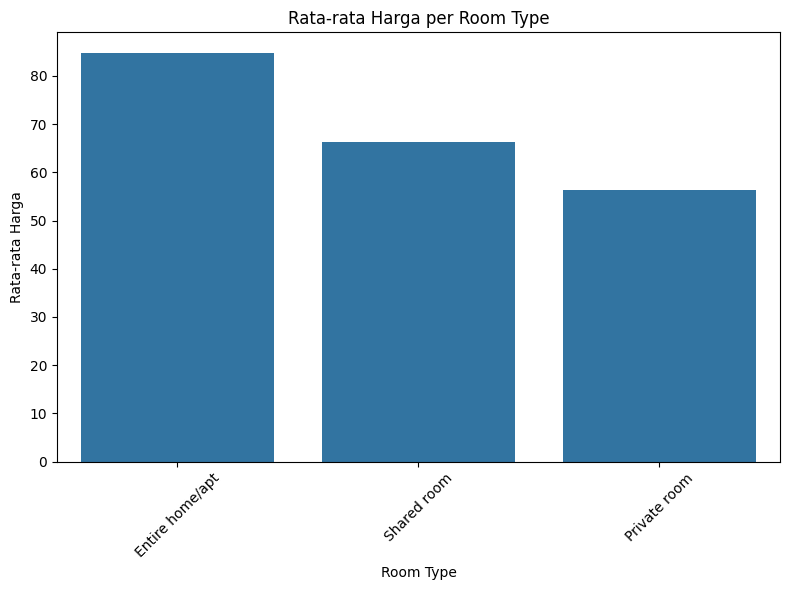

In [156]:
# Check correlation between room_type and price
import seaborn as sns

avg_price_per_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False)

# Make bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=avg_price_per_room.index, y=avg_price_per_room.values)
plt.title('Rata-rata Harga per Room Type')
plt.xlabel('Room Type')
plt.ylabel('Rata-rata Harga')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Check missing values (nilai yang kosong)

In [157]:
# 2.c some columns have a lot of missing values.
# try to understand how the following comand works.
# try to execute df.isna() only, then df.isna().sum() ...

df.isna().sum().sort_values(ascending=False)

,0
square_feet,13260
cleaning_fee,4272
review_scores_value,2678
beds,29
bathrooms,23
bedrooms,11
price,0
id,0
latitude,0
neighbourhood_group_cleansed,0


In [158]:
# 2.d fill ne missing values with the mean value, check with the above command that
# no missing values are left
df = df.fillna(df.select_dtypes('number').mean())
df.isna().sum().sort_values(ascending=False)

,0
id,0
price,0
neighbourhood_group_cleansed,0
latitude,0
longitude,0
bathrooms,0
availability_30,0
beds,0
bedrooms,0
review_scores_value,0


## Check CORRELATIONS for each columns, expecially for PRICE

In [159]:
# 2.d compute the corelations and look which features have a high corelation with price
# df.corr().style.background_gradient()
df.select_dtypes(include='number').corr().style.background_gradient()

,id,price,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,minimum_nights,maximum_nights,availability_365,cleaning_fee,square_feet,guests_included
id,1.000000,0.036903,0.000890,-0.021492,-0.009163,0.124149,-0.054175,-0.078555,0.034258,-0.039821,-0.007156,-0.063357,-0.081665,-0.002346,-0.073048
price,0.036903,1.000000,-0.000523,-0.043415,0.056410,0.113626,0.093743,0.105298,-0.030973,0.006582,-0.000835,0.103613,0.243949,0.011013,0.093485
latitude,0.000890,-0.000523,1.000000,-0.103196,0.002291,-0.007762,0.015873,0.010359,-0.007964,0.012127,0.008208,0.004840,0.028375,-0.010605,0.030783
longitude,-0.021492,-0.043415,-0.103196,1.000000,0.000848,-0.052582,-0.005210,0.008254,0.017827,-0.024320,-0.004821,-0.082404,-0.045074,0.000221,-0.001144
bathrooms,-0.009163,0.056410,0.002291,0.000848,1.000000,0.036989,0.267756,0.300103,-0.003459,-0.004560,-0.003453,0.039848,0.110863,0.041437,0.159584
availability_30,0.124149,0.113626,-0.007762,-0.052582,0.036989,1.000000,0.128834,0.040929,-0.054270,0.032532,0.012623,0.541278,0.074724,0.001048,0.082160
beds,-0.054175,0.093743,0.015873,-0.005210,0.267756,0.128834,1.000000,0.615204,-0.089233,0.010716,-0.006461,0.191947,0.219194,0.077113,0.445370
bedrooms,-0.078555,0.105298,0.010359,0.008254,0.300103,0.040929,0.615204,1.000000,-0.021724,0.000833,-0.002958,0.075513,0.211437,0.076173,0.372031
review_scores_value,0.034258,-0.030973,-0.007964,0.017827,-0.003459,-0.054270,-0.089233,-0.021724,1.000000,-0.013551,-0.006510,-0.090955,-0.090198,-0.007284,-0.062850
minimum_nights,-0.039821,0.006582,0.012127,-0.024320,-0.004560,0.032532,0.010716,0.000833,-0.013551,1.000000,-0.001543,0.088981,0.084426,-0.005234,0.012834


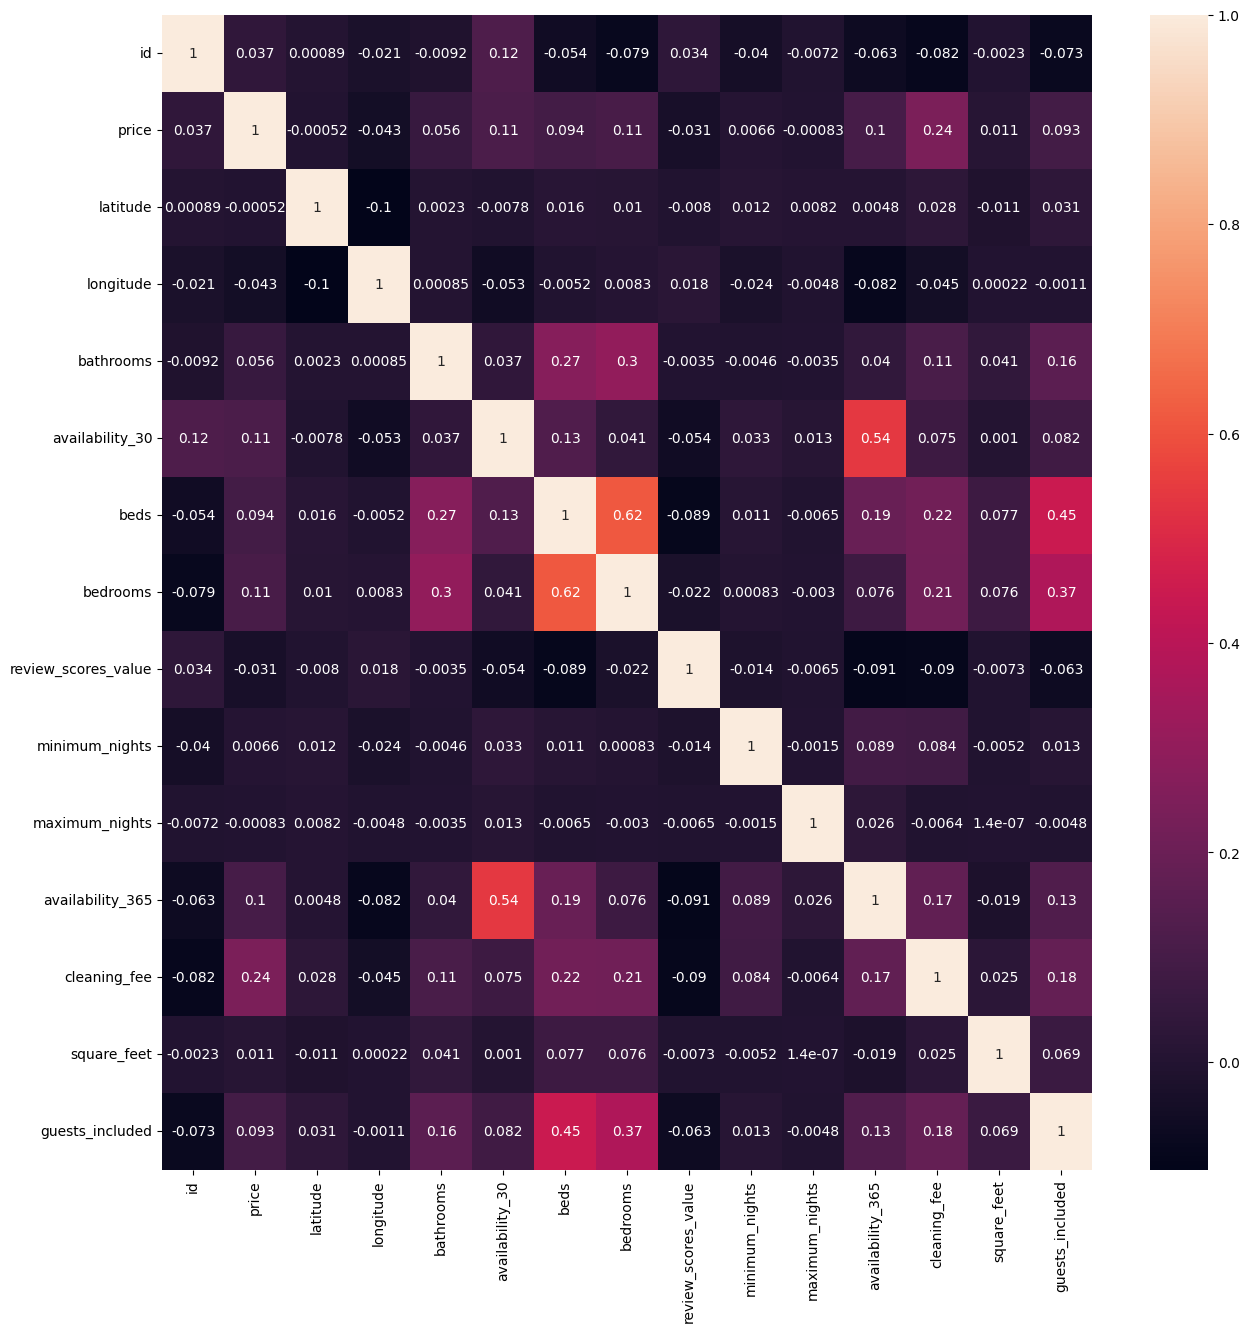

In [160]:
import seaborn as sns

corr_matrix = df.select_dtypes('number').corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, annot=True)
plt.show()


In [161]:
# Features correlations with 'price'
korelasi_price = df.select_dtypes('number').corr()['price'].sort_values(ascending=False)

# Tampilkan hasil
print(korelasi_price)

price                  1.000000
cleaning_fee           0.243949
availability_30        0.113626
bedrooms               0.105298
availability_365       0.103613
beds                   0.093743
guests_included        0.093485
bathrooms              0.056410
id                     0.036903
square_feet            0.011013
minimum_nights         0.006582
latitude              -0.000523
maximum_nights        -0.000835
review_scores_value   -0.030973
longitude             -0.043415
Name: price, dtype: float64


## Check NAN Values

In [201]:
# Menampilkan kolom yang memiliki nilai NaN
nan_count = df.isna().sum()  # Atau df.isnull().sum()
print("NaN detection: \n", nan_count)

NaN detection: 
 id                              0
price                           0
neighbourhood_group_cleansed    0
latitude                        0
longitude                       0
bathrooms                       0
availability_30                 0
beds                            0
bedrooms                        0
review_scores_value             0
bed_type                        0
minimum_nights                  0
maximum_nights                  0
availability_365                0
property_type                   0
is_business_travel_ready        0
cleaning_fee                    0
room_type                       0
square_feet                     0
guests_included                 0
room_type_encoded               0
dtype: int64


## Check OUTLIERS using BOXPLOT

In [162]:
outlier_summary = {}

# Ambil kolom numerik saja
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Simpan hasil
    outlier_summary[col] = {
        'jumlah_outlier': outliers.shape[0],
        # 'nilai_outlier': outliers[col].tolist()
    }

# Tampilkan sebagai DataFrame
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index')
print(outlier_df)

                     jumlah_outlier
id                                0
price                           770
latitude                        159
longitude                       440
bathrooms                      1667
availability_30                1996
beds                            877
bedrooms                       3240
review_scores_value             249
minimum_nights                 1480
maximum_nights                    9
availability_365               1036
cleaning_fee                    795
square_feet                     271
guests_included                3059


In [163]:
df.describe()

,id,price,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,minimum_nights,maximum_nights,availability_365,cleaning_fee,square_feet,guests_included
count,1.353100e+04,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,13531.000000,1.353100e+04,13531.000000,13531.000000,13531.000000,13531.000000
mean,1.573089e+07,70.082625,52.509956,13.405871,1.095203,4.976498,1.627092,1.158728,9.408458,7.187421,1.484241e+05,80.442687,26.871368,480.416974,1.334122
std,8.580394e+06,255.451132,0.030773,0.058517,0.335184,8.692006,1.179820,0.652097,0.763172,47.773700,1.215720e+07,119.588978,27.292448,73.411566,0.839897
min,2.695000e+03,0.000000,52.346203,13.103557,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000
25%,8.041528e+06,30.000000,52.489082,13.374950,1.000000,0.000000,1.000000,1.000000,9.000000,2.000000,2.000000e+01,0.000000,15.000000,480.416974,1.000000
50%,1.697254e+07,45.000000,52.509229,13.416764,1.000000,0.000000,1.000000,1.000000,9.408458,2.000000,1.124000e+03,4.000000,26.871368,480.416974,1.000000
75%,2.264464e+07,70.000000,52.532808,13.439258,1.000000,6.000000,2.000000,1.000000,10.000000,4.000000,1.125000e+03,130.000000,30.000000,480.416974,1.000000
max,2.986735e+07,9000.000000,52.651670,13.721671,8.500000,30.000000,22.000000,12.000000,10.000000,5000.000000,1.000000e+09,365.000000,2000.000000,4639.000000,16.000000


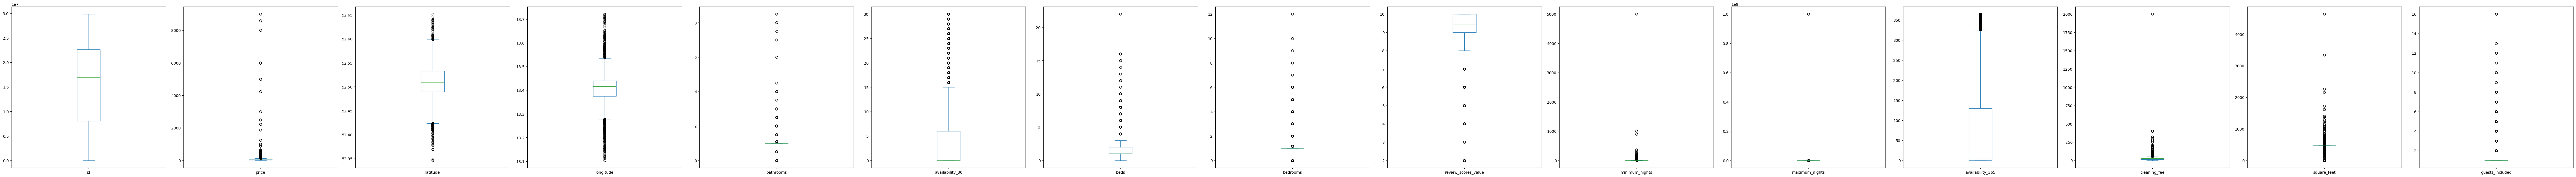

In [164]:
df.select_dtypes('number').plot(kind='box', subplots=True, layout=(16, 16), figsize=(100, 100), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

In [165]:
# Counts outliers from some columns

def detect_outlier_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

# Check outliers for each column
outlier_beds = detect_outlier_iqr(df['beds'])
outlier_bedrooms = detect_outlier_iqr(df['bedrooms'])
outlier_bathroom = detect_outlier_iqr(df['bathrooms'])

# Sum all the outliers
combined_outlier = outlier_beds | outlier_bedrooms | outlier_bathroom

# Counts duplicate columns
total_outlier_rows = combined_outlier.sum()

print(f"total outliers: {total_outlier_rows}")


total outliers: 4376


# Pre-Processing Step-1
let's try without pre-processing (perisapan/pembersihan data)

# Modelling

## Model 1 (without well pre-processing)

In [166]:
# load functions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

In [167]:
# 2.e define a feature dataframe with 3 features and the target column price
# create a train and test dataset
X = df[['square_feet','cleaning_fee', 'latitude','longitude','bedrooms','review_scores_value','minimum_nights']]
y_target = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.3)

In [168]:
# 2.f train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

model.predict(X_train)

array([60.42202127, 51.2394286 , 75.62590365, ..., 65.70083545,
       88.411836  , 63.48935641])

In [169]:
# 2.g test your model part 1
y_predict = model.predict(X_test)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
print(rmse)   # Model evaluation

262.2988451226347


In [170]:
# Print result of predict
hasil_prediksi = X_test.copy()
hasil_prediksi['harga_asli'] = y_test.values
hasil_prediksi['harga_prediksi'] = y_predict

# Show the first 5 row
print(hasil_prediksi.head())

       square_feet  cleaning_fee   latitude  longitude  bedrooms  \
1209    480.416974     15.000000  52.493654  13.350252       1.0   
7013    480.416974     10.000000  52.471877  13.449634       1.0   
1546    480.416974     30.000000  52.509055  13.415563       2.0   
1748    480.416974     26.871368  52.555270  13.413417       0.0   
12783   480.416974      0.000000  52.504566  13.447621       1.0   

       review_scores_value  minimum_nights  harga_asli  harga_prediksi  
1209                   8.0               2        80.0       70.681403  
7013                   9.0               3        25.0       50.697772  
1546                  10.0              60        76.0       75.810741  
1748                  10.0               1        20.0       33.915501  
12783                  9.0               3        40.0       42.952574  


# Pre-processing step-2

In [171]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  float64
 2   neighbourhood_group_cleansed  13531 non-null  object 
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13531 non-null  float64
 6   availability_30               13531 non-null  int64  
 7   beds                          13531 non-null  float64
 8   bedrooms                      13531 non-null  float64
 9   review_scores_value           13531 non-null  float64
 10  bed_type                      13531 non-null  object 
 11  minimum_nights                13531 non-null  int64  
 12  maximum_nights                13531 non-null  int64  
 13  a

### Missing values handling

In [172]:
# Clean missing values
df = df.fillna(df.select_dtypes('number').mean())
df.isna().sum().sort_values(ascending=False)

# NO NEED, ALREADY IN EDA SESSION

,0
id,0
price,0
neighbourhood_group_cleansed,0
latitude,0
longitude,0
bathrooms,0
availability_30,0
beds,0
bedrooms,0
review_scores_value,0


### Outliers handling

In [173]:
# Check outliers
outlier_summary = {}

# Get only numeric columns
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter outlier
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Simpan hasil
    outlier_summary[col] = {
        'jumlah_outlier': outliers.shape[0],
        # 'nilai_outlier': outliers[col].tolist()
    }

# Show as DataFrame
outlier_df = pd.DataFrame.from_dict(outlier_summary, orient='index')
print(outlier_df)

                     jumlah_outlier
id                                0
price                           770
latitude                        159
longitude                       440
bathrooms                      1667
availability_30                1996
beds                            877
bedrooms                       3240
review_scores_value             249
minimum_nights                 1480
maximum_nights                    9
availability_365               1036
cleaning_fee                    795
square_feet                     271
guests_included                3059


In [174]:
# Outliers handling (cleaning outliers)
def cap_outliers_with_report(df):
    import pandas as pd

    # Copy the dataframe so as not to corrupt the original data
    df_cleaned = df.copy()
    outlier_report = {}

    # Get all numeric columns
    numeric_cols = df_cleaned.select_dtypes(include='number').columns

    for col in numeric_cols:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count the number of outliers before cleaning
        outliers_before = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)].shape[0]

        # Replace outlier values with lower/upper limits
        df_cleaned[col] = df_cleaned[col].apply(lambda x: lower_bound if x < lower_bound else x)
        df_cleaned[col] = df_cleaned[col].apply(lambda x: upper_bound if x > upper_bound else x)

        # Count the number of outliers after cleaning (should be 0)
        outliers_after = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)].shape[0]

        # Simpan laporan
        outlier_report[col] = {
            'outliers_sebelum': outliers_before,
            'outliers_sesudah': outliers_after,
            'lower_bound': round(lower_bound, 2),
            'upper_bound': round(upper_bound, 2)
        }

    # Show as dataFrame
    report_df = pd.DataFrame.from_dict(outlier_report, orient='index')
    print("📊 Outliers information after handing/cleaning:")
    print(report_df)

    return df_cleaned
df = cap_outliers_with_report(df)

📊 Outliers information after handing/cleaning:
                     outliers_sebelum  outliers_sesudah  lower_bound  \
id                                  0                 0 -13863136.00   
price                             770                 0       -30.00   
latitude                          159                 0        52.42   
longitude                         440                 0        13.28   
bathrooms                        1667                 0         1.00   
availability_30                  1996                 0        -9.00   
beds                              877                 0        -0.50   
bedrooms                         3240                 0         1.00   
review_scores_value               249                 0         7.50   
minimum_nights                   1480                 0        -1.00   
maximum_nights                      9                 0     -1637.50   
availability_365                 1036                 0      -195.00   
cleaning_fee     

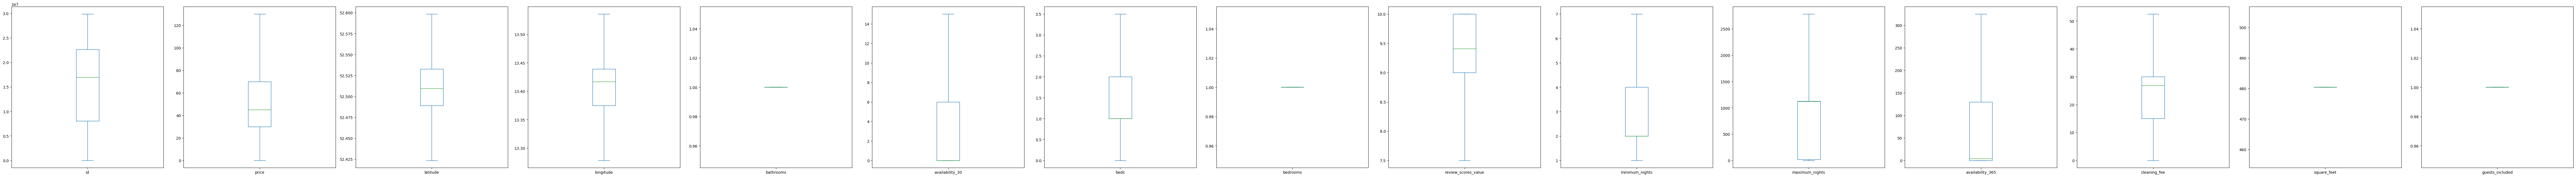

In [175]:
# Check outliers after cleaning
df.select_dtypes('number').plot(kind='box', subplots=True, layout=(16, 16), figsize=(100, 100), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

# Model 2 (with good pre-processing)

In [176]:
# 2.e define a feature dataframe with 3 features and the target column price
# create a train and test dataset
X = df[['square_feet','cleaning_fee', 'latitude','longitude','bedrooms','review_scores_value','minimum_nights']]
y_target = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.3)

In [177]:
# 2.f train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

model.predict(X_train)

array([63.40440459, 54.05070634, 30.77122697, ..., 61.17858246,
       56.87723703, 36.72904973])

In [178]:
# 2.g test your model part 2
y_predict = model.predict(X_test)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
print(rmse)   # Model evaluation

27.630980169456723


In [179]:
# Print result of predict
hasil_prediksi = X_test.copy()
hasil_prediksi['harga_asli'] = y_test.values
hasil_prediksi['harga_prediksi'] = y_predict

# Show the first 5 row
print(hasil_prediksi.head())

       square_feet  cleaning_fee   latitude  longitude  bedrooms  \
9604    480.416974     26.871368  52.505891  13.469745       1.0   
12534   480.416974      8.000000  52.501446  13.431682       1.0   
3824    480.416974     25.000000  52.483742  13.429784       1.0   
11593   480.416974     52.500000  52.531994  13.405905       1.0   
889     480.416974     15.000000  52.543354  13.410773       1.0   

       review_scores_value  minimum_nights  harga_asli  harga_prediksi  
9604             10.000000             3.0        20.0       54.719992  
12534            10.000000             1.0        30.0       38.830151  
3824              9.000000             2.0        70.0       55.747798  
11593             9.000000             7.0        55.0       79.647368  
889               9.408458             3.0        30.0       46.987802  


# Model 3 (with selection features and good pre-processing)

In [186]:
# use high correlations
X = df[['cleaning_fee', 'availability_30','bedrooms','availability_365', 'beds','guests_included','bathrooms', 'square_feet', 'minimum_nights']]
y_target = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.3)

In [187]:
# 2.f train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

model.predict(X_train)

array([76.9796794 , 43.72235198, 68.73803969, ..., 40.39229622,
       77.46954469, 57.91507817])

In [188]:
# 2.g test your model part 2
y_predict = model.predict(X_test)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
print(rmse)   # Model evaluation

25.060289327880717


In [189]:
# Print result of predict
hasil_prediksi = X_test.copy()
hasil_prediksi['harga_asli'] = y_test.values
hasil_prediksi['harga_prediksi'] = y_predict

# Show the first 5 row
print(hasil_prediksi.head())

       cleaning_fee  availability_30  bedrooms  availability_365  beds  \
11806     30.000000              0.0       1.0              98.0   1.0   
6036       0.000000             10.0       1.0             325.0   1.0   
3829      30.000000              0.0       1.0               0.0   1.0   
592       26.871368              0.0       1.0               0.0   2.0   
1917      26.871368              0.0       1.0               0.0   1.0   

       guests_included  bathrooms  square_feet  minimum_nights  harga_asli  \
11806              1.0        1.0   480.416974             4.0        35.0   
6036               1.0        1.0   480.416974             5.0        25.0   
3829               1.0        1.0   480.416974             6.0        69.0   
592                1.0        1.0   480.416974             1.0        25.0   
1917               1.0        1.0   480.416974             2.0        45.0   

       harga_prediksi  
11806       48.443733  
6036        36.919659  
3829        46

# Pre-Processing Step-3
with label encoder

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  float64
 2   neighbourhood_group_cleansed  13531 non-null  object 
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13531 non-null  float64
 6   availability_30               13531 non-null  float64
 7   beds                          13531 non-null  float64
 8   bedrooms                      13531 non-null  float64
 9   review_scores_value           13531 non-null  float64
 10  bed_type                      13531 non-null  object 
 11  minimum_nights                13531 non-null  float64
 12  maximum_nights                13531 non-null  float64
 13  a

## Features correlation

In [190]:
# Features correlations with 'price'
korelasi_price = df.select_dtypes('number').corr()['price'].sort_values(ascending=False)

# Tampilkan hasil
print(korelasi_price)

price                  1.000000
beds                   0.467383
cleaning_fee           0.421950
availability_365       0.236415
availability_30        0.213638
maximum_nights         0.067878
latitude               0.056665
minimum_nights         0.023901
id                    -0.006165
longitude             -0.040048
review_scores_value   -0.092246
bathrooms                   NaN
bedrooms                    NaN
square_feet                 NaN
guests_included             NaN
Name: price, dtype: float64


## Label encoder

In [191]:
# Label Encoder for some columns (room_type)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['room_type_encoded'] = le.fit_transform(df['room_type'])

In [192]:
from sklearn.preprocessing import LabelEncoder

# Copy the dataframe so as not to corrupt the original data
df_encoded = df.copy()

# Loop semua kolom non-numerik
label_encoders = {}
for col in df_encoded.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le  # Simpan encoder jika ingin inverse_transform nanti

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13531 entries, 0 to 13530
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            13531 non-null  int64  
 1   price                         13531 non-null  float64
 2   neighbourhood_group_cleansed  13531 non-null  int64  
 3   latitude                      13531 non-null  float64
 4   longitude                     13531 non-null  float64
 5   bathrooms                     13531 non-null  float64
 6   availability_30               13531 non-null  float64
 7   beds                          13531 non-null  float64
 8   bedrooms                      13531 non-null  float64
 9   review_scores_value           13531 non-null  float64
 10  bed_type                      13531 non-null  int64  
 11  minimum_nights                13531 non-null  float64
 12  maximum_nights                13531 non-null  float64
 13  a

In [193]:
df_encoded.head()

,id,price,neighbourhood_group_cleansed,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,...,minimum_nights,maximum_nights,availability_365,property_type,is_business_travel_ready,cleaning_fee,room_type,square_feet,guests_included,room_type_encoded
0,28684898,50.0,5,52.473978,13.454423,1.0,15.0,2.0,1.0,9.000000,...,1.0,13.0,73.0,1,0,0.000000,1,480.416974,1.0,1
1,22607348,10.0,11,52.468095,13.487103,1.0,0.0,1.0,1.0,9.000000,...,7.0,1124.0,156.0,1,0,26.871368,1,480.416974,1.0,1
2,21019199,35.0,5,52.481810,13.437268,1.0,0.0,1.0,1.0,9.000000,...,1.0,1125.0,0.0,1,0,15.000000,1,480.416974,1.0,1
3,21919556,99.0,6,52.537269,13.416036,1.0,0.0,2.0,1.0,9.408458,...,7.0,41.0,35.0,1,0,50.000000,0,480.416974,1.0,0
4,4820648,39.0,1,52.491483,13.387362,1.0,0.0,1.0,1.0,9.000000,...,7.0,1125.0,289.0,1,0,26.871368,0,480.416974,1.0,0


# Model 4 (use high correlation and with encoding)

In [206]:
# Features correlations with 'price'
korelasi_price = df_encoded.select_dtypes('number').corr()['price'].sort_values(ascending=False)

# Tampilkan hasil
print(korelasi_price)

price                           1.000000
beds                            0.467383
cleaning_fee                    0.421950
availability_365                0.236415
availability_30                 0.213638
property_type                   0.177653
maximum_nights                  0.067878
bed_type                        0.057966
latitude                        0.056665
minimum_nights                  0.023901
id                             -0.006165
neighbourhood_group_cleansed   -0.034109
longitude                      -0.040048
review_scores_value            -0.092246
room_type                      -0.528605
room_type_encoded              -0.528605
bathrooms                            NaN
bedrooms                             NaN
is_business_travel_ready             NaN
square_feet                          NaN
guests_included                      NaN
Name: price, dtype: float64


In [207]:
df_encoded.head()

,id,price,neighbourhood_group_cleansed,latitude,longitude,bathrooms,availability_30,beds,bedrooms,review_scores_value,...,minimum_nights,maximum_nights,availability_365,property_type,is_business_travel_ready,cleaning_fee,room_type,square_feet,guests_included,room_type_encoded
0,28684898,50.0,5,52.473978,13.454423,1.0,15.0,2.0,1.0,9.000000,...,1.0,13.0,73.0,1,0,0.000000,1,480.416974,1.0,1
1,22607348,10.0,11,52.468095,13.487103,1.0,0.0,1.0,1.0,9.000000,...,7.0,1124.0,156.0,1,0,26.871368,1,480.416974,1.0,1
2,21019199,35.0,5,52.481810,13.437268,1.0,0.0,1.0,1.0,9.000000,...,1.0,1125.0,0.0,1,0,15.000000,1,480.416974,1.0,1
3,21919556,99.0,6,52.537269,13.416036,1.0,0.0,2.0,1.0,9.408458,...,7.0,41.0,35.0,1,0,50.000000,0,480.416974,1.0,0
4,4820648,39.0,1,52.491483,13.387362,1.0,0.0,1.0,1.0,9.000000,...,7.0,1125.0,289.0,1,0,26.871368,0,480.416974,1.0,0


In [208]:
# 2.e define a feature dataframe with 3 features and the target column price
# create a train and test dataset
X = df_encoded[['beds', 'cleaning_fee','availability_365','availability_30','property_type','minimum_nights', 'maximum_nights', 'room_type']]
y_target = df_encoded['price']

X_train, X_test, y_train, y_test = train_test_split(X, y_target, test_size=0.3)

In [209]:
# 2.f train a linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

model.predict(X_train)

array([56.91950738, 28.49240836, 52.09542521, ..., 82.27372713,
       58.97916412, 47.18930064])

In [210]:
# 2.g test your model part 4
y_predict = model.predict(X_test)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)
print(rmse)   # Model evaluation

23.210617023658294


In [211]:
# Print result of predict
hasil_prediksi = X_test.copy()
hasil_prediksi['harga_asli'] = y_test.values
hasil_prediksi['harga_prediksi'] = y_predict

# Show the first 5 row of predict
print(hasil_prediksi.head())

       beds  cleaning_fee  availability_365  availability_30  property_type  \
11408   1.0     26.871368             231.0              4.0              1   
5219    1.0     26.871368               0.0              0.0              1   
10162   2.0      0.000000               4.0              4.0              1   
487     1.0     10.000000               0.0              0.0              1   
4926    1.0     26.871368               0.0              0.0              1   

       minimum_nights  maximum_nights  room_type  harga_asli  harga_prediksi  
11408             5.0            30.0          0        70.0       59.987277  
5219              1.0          1125.0          1        22.0       38.807799  
10162             2.0          1125.0          1        55.0       39.014510  
487               5.0          1125.0          1        25.0       26.572482  
4926              1.0          1125.0          1        40.0       38.807799  


# Final Model and Visualisation

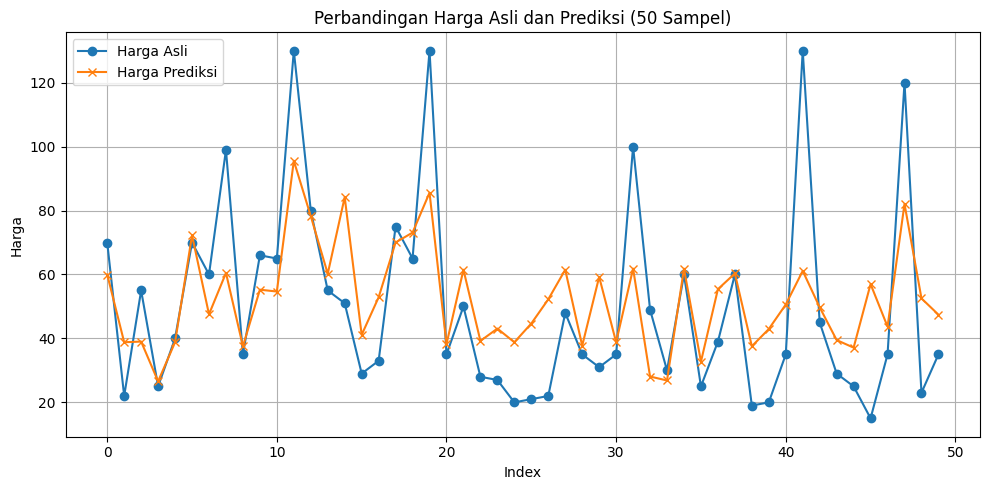

In [213]:
plt.figure(figsize=(10,5))
plt.plot(hasil_prediksi['harga_asli'].values[:50], label='Harga Asli', marker='o')
plt.plot(hasil_prediksi['harga_prediksi'].values[:50], label='Harga Prediksi', marker='x')
plt.title('Perbandingan Harga Asli dan Prediksi (50 Sampel)')
plt.xlabel('Index')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
